In [164]:
#1. Importing the libraries
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as pt
import plotly.express as ex
import plotly.io as pio
pio.renderers.default='svg'


In [165]:
#2. Importing the dataset
dataset=pd.read_csv("Zomato_Mumbai_Dataset.csv",delimiter="|")

In [166]:
dataset.head

<bound method NDFrame.head of                     NAME PRICE  \
0                Hitchki  1200   
1           Baba Falooda   400   
2          Chin Chin Chu  1800   
3         Butterfly High  1000   
4              BKC  DIVE  1200   
...                  ...   ...   
15076  Hari Om Snack Bar   350   
15077           PitaBurg   400   
15078     Uncha Otlawala   300   
15079     Mandarin Panda   400   
15080                     NaN   

                                         CUSINE_CATEGORY    CITY  \
0      Modern Indian,North Indian,Chinese,Momos,Birya...  Mumbai   
1                           Desserts,Ice Cream,Beverages  Mumbai   
2                                          Asian,Chinese  Mumbai   
3                                          Modern Indian  Mumbai   
4                       North Indian,Chinese,Continental  Mumbai   
...                                                  ...     ...   
15076                     Fast Food,South Indian,Chinese  Mumbai   
15077            

In [167]:
#3. Getting Basic Information about the Dataset
dataset.shape

(15081, 12)

In [168]:
dataset.info

<bound method DataFrame.info of                     NAME PRICE  \
0                Hitchki  1200   
1           Baba Falooda   400   
2          Chin Chin Chu  1800   
3         Butterfly High  1000   
4              BKC  DIVE  1200   
...                  ...   ...   
15076  Hari Om Snack Bar   350   
15077           PitaBurg   400   
15078     Uncha Otlawala   300   
15079     Mandarin Panda   400   
15080                     NaN   

                                         CUSINE_CATEGORY    CITY  \
0      Modern Indian,North Indian,Chinese,Momos,Birya...  Mumbai   
1                           Desserts,Ice Cream,Beverages  Mumbai   
2                                          Asian,Chinese  Mumbai   
3                                          Modern Indian  Mumbai   
4                       North Indian,Chinese,Continental  Mumbai   
...                                                  ...     ...   
15076                     Fast Food,South Indian,Chinese  Mumbai   
15077          

In [169]:
dataset.describe

<bound method NDFrame.describe of                     NAME PRICE  \
0                Hitchki  1200   
1           Baba Falooda   400   
2          Chin Chin Chu  1800   
3         Butterfly High  1000   
4              BKC  DIVE  1200   
...                  ...   ...   
15076  Hari Om Snack Bar   350   
15077           PitaBurg   400   
15078     Uncha Otlawala   300   
15079     Mandarin Panda   400   
15080                     NaN   

                                         CUSINE_CATEGORY    CITY  \
0      Modern Indian,North Indian,Chinese,Momos,Birya...  Mumbai   
1                           Desserts,Ice Cream,Beverages  Mumbai   
2                                          Asian,Chinese  Mumbai   
3                                          Modern Indian  Mumbai   
4                       North Indian,Chinese,Continental  Mumbai   
...                                                  ...     ...   
15076                     Fast Food,South Indian,Chinese  Mumbai   
15077        

In [170]:
dataset.columns

Index(['NAME', 'PRICE', 'CUSINE_CATEGORY', 'CITY', 'REGION', 'URL', 'PAGE NO',
       'CUSINE TYPE', 'TIMING', 'RATING_TYPE', 'RATING', 'VOTES'],
      dtype='str')

In [171]:
"""
4. Cleaning the Dataset
a. Removing the redundunt rows of data
# Checking redundunt rows of data 
"""
wrong_data=dataset['PAGE NO']=='PAGE NO'
wrong_data


0        False
1        False
2        False
3        False
4        False
         ...  
15076    False
15077    False
15078    False
15079    False
15080    False
Name: PAGE NO, Length: 15081, dtype: bool

In [90]:
# Dropping columns which are not required for further analysis 
dataset.drop(['URL', 'PAGE NO', 'CITY'], axis = 1,inplace=True)

In [91]:
dataset.head

<bound method NDFrame.head of                     NAME PRICE  \
0                Hitchki  1200   
1           Baba Falooda   400   
2          Chin Chin Chu  1800   
3         Butterfly High  1000   
4              BKC  DIVE  1200   
...                  ...   ...   
15076  Hari Om Snack Bar   350   
15077           PitaBurg   400   
15078     Uncha Otlawala   300   
15079     Mandarin Panda   400   
15080                     NaN   

                                         CUSINE_CATEGORY  \
0      Modern Indian,North Indian,Chinese,Momos,Birya...   
1                           Desserts,Ice Cream,Beverages   
2                                          Asian,Chinese   
3                                          Modern Indian   
4                       North Indian,Chinese,Continental   
...                                                  ...   
15076                     Fast Food,South Indian,Chinese   
15077                                 Fast Food,Lebanese   
15078                

In [93]:
"""
b. Removing the Null Records
 # Checking for Null records
"""
dataset.isnull().sum()

NAME                  0
PRICE                 1
CUSINE_CATEGORY       2
REGION                1
CUSINE TYPE           1
TIMING               66
RATING_TYPE        1011
RATING                1
VOTES                 1
dtype: int64

In [94]:
# Checking for a null row 
dataset[dataset['PRICE'].isnull()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
15080,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
# Droping the above row from the dataset 
dataset=dataset.drop(labels=15080, axis =0)
dataset

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am(Mon-Sun),Very Good,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am(Mon-Sun),Very Good,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am(Mon-Sun),Veľmi dobré,4.4,5995
...,...,...,...,...,...,...,...,...,...
15075,Tirupati Balaji,500,"Chinese,Fast Food,North Indian",Oshiwara-- Andheri West,Casual Dining,"8am to 11pm,12midnight to 115am(Mon-Sun)",Good,3.5,267
15076,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali West,Quick Bites,11am to 230am(Mon-Sun),Good,3.7,64
15077,PitaBurg,400,"Fast Food,Lebanese",Lower Parel,none,"11am to 11pm(Mon,Tue,Wed,Thu,Sun),11am to ...",Average,3.4,99
15078,Uncha Otlawala,300,"Desserts,Ice Cream",Kandivali West,Dessert Parlor,9am to 1230AM(Mon-Sun),Good,3.5,29


In [96]:
 # Replacing the other null records with NA 
dataset.fillna('NA',inplace=True)

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am(Mon-Sun),Excellent,4.9,3529
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am(Mon-Sun),Very Good,4.4,1723
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am(Mon-Sun),Very Good,4.2,337
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am(Mon-Sun),Very Good,4.3,1200
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am(Mon-Sun),Veľmi dobré,4.4,5995
...,...,...,...,...,...,...,...,...,...
15075,Tirupati Balaji,500,"Chinese,Fast Food,North Indian",Oshiwara-- Andheri West,Casual Dining,"8am to 11pm,12midnight to 115am(Mon-Sun)",Good,3.5,267
15076,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali West,Quick Bites,11am to 230am(Mon-Sun),Good,3.7,64
15077,PitaBurg,400,"Fast Food,Lebanese",Lower Parel,none,"11am to 11pm(Mon,Tue,Wed,Thu,Sun),11am to ...",Average,3.4,99
15078,Uncha Otlawala,300,"Desserts,Ice Cream",Kandivali West,Dessert Parlor,9am to 1230AM(Mon-Sun),Good,3.5,29


In [97]:
 # Confirming all the null records are correct 
dataset.isnull().sum()

NAME               0
PRICE              0
CUSINE_CATEGORY    0
REGION             0
CUSINE TYPE        0
TIMING             0
RATING_TYPE        0
RATING             0
VOTES              0
dtype: int64

In [98]:
"""c. Converting the DataTypes of numerical columns to numeric dataype
# Checking for text values in the column before converting it to numeric datatype 
"""
dataset['RATING'].value_counts()

RATING
-          2360
3.5        1094
3.4        1036
3.6         960
NEW         953
RATING      942
3.3         926
3.7         917
3.2         801
3.8         782
3.1         734
3.0         622
3.9         596
2.9         409
4.0         408
2.8         309
4.1         298
4.2         199
2.7         170
4.3         148
4.4          99
2.6          77
Opening      57
4.5          46
2.5          39
4.6          32
2.4          26
4.7          13
2.3          10
2.1           5
4.8           4
2.2           4
4.9           2
1.8           1
2.0           1
Name: count, dtype: int64

In [99]:
 # Replacing the text values with '0' 
dataset['RATING']=dataset['RATING'].replace(['-','NEW','Opening','Opening','RATING'], value='0', inplace=True) 

C:\Users\Diwali 6\AppData\Local\Temp\ipykernel_15488\1354745243.py:2: ChainedAssignmentError:

A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html



In [100]:
dataset['RATING'].unique()

<StringArray>
['4.9', '4.4', '4.2', '4.3', '4.5', '4.7', '4.0', '4.6', '4.1',   '0', '3.9',
 '3.8', '3.6', '3.4', '3.0', '3.7', '4.8', '3.3', '3.5', '3.2', '3.1', '2.7',
 '2.5', '2.8', '2.6', '2.3', '2.9', '2.4', '2.1', '2.2', '1.8', '2.0']
Length: 32, dtype: str

In [101]:
 # Checking for text values in the column before converting it to numeric datatype 
dataset['VOTES'].value_counts()

VOTES
-        2360
NEW       953
VOTES     942
4         364
5         320
         ... 
754         1
914         1
944         1
861         1
1249        1
Name: count, Length: 1124, dtype: int64

In [102]:
 # Replacing the text values with '0'
dataset['VOTES']=dataset['VOTES'].replace(to_replace=['-','NEW','Opening','VOTES'], value='0', inplace=True) 

C:\Users\Diwali 6\AppData\Local\Temp\ipykernel_15488\1243436563.py:2: ChainedAssignmentError:

A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html



In [103]:
dataset['VOTES'].unique()

<StringArray>
['3529', '1723',  '337', '1200', '5995', '2042', '3058', '1842', '2797',
 '1876',
 ...
 '1608', '1653',  '702',  '660', '2301',  '754',  '914',  '944',  '861',
 '1249']
Length: 1120, dtype: str

In [104]:
dataset['PRICE'].value_counts()

PRICE
400     2042
500     1954
300     1936
200     1177
600     1062
        ... 
80         1
360        1
3502       1
248        1
2700       1
Name: count, Length: 67, dtype: int64

In [105]:
dataset['PRICE']=dataset['PRICE'].replace(to_replace=['PRICE','nan'], value='0', inplace=True)

C:\Users\Diwali 6\AppData\Local\Temp\ipykernel_15488\652271279.py:1: ChainedAssignmentError:

A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html



In [106]:
dataset['PRICE'].unique()


<StringArray>
['1200',  '400', '1800', '1000',  '800', '1300', '1500',  '600', '1400',
 '1100',    '0', '2000',  '350',  '900',  '700',  '500', '1600',  '150',
  '300',  '550',  '450',  '650',  '750',  '250',  '200',  '850',  '100',
 '2500', '1450',  '180',  '950', '1700', '1900', '2600', '2400', '3000',
 '1250', '3200',  '505', '2200', '1050', '1650', '1350',   '50',  '920',
 '1150', '1550', '3500',  '398', '5000',  '120',  '220',  '160',  '340',
    '5',  '480', '2100',  '580', '1850',  '249',   '80', '2300',  '360',
 '3502',  '248', '2700']
Length: 66, dtype: str

In [107]:
# Changing Data Type of the numerical columns 
 
dataset['PRICE'] = dataset['PRICE'].astype('int64') 
dataset['RATING'] = dataset['RATING'].astype('float64') 
dataset['VOTES'] = dataset['VOTES'].astype('int64') 

In [108]:
dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 15080 entries, 0 to 15079
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NAME             15080 non-null  str    
 1   PRICE            15080 non-null  int64  
 2   CUSINE_CATEGORY  15080 non-null  str    
 3   REGION           15080 non-null  str    
 4   CUSINE TYPE      15080 non-null  str    
 5   TIMING           15080 non-null  str    
 6   RATING_TYPE      15080 non-null  str    
 7   RATING           15080 non-null  float64
 8   VOTES            15080 non-null  int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 1.0 MB


In [111]:
#d. Working with 'Timing' column
dataset['TIMING'].value_counts()

TIMING
11am to 11pm(Mon-Sun)                               1192
TIMING                                               942
11am to 12midnight(Mon-Sun)                          632
12noon to 12midnight(Mon-Sun)                        467
11am to 1130pm(Mon-Sun)                              309
                                                    ... 
9am to 9pm(Mon-Sat),9am to 10pm(Sun)                   1
Closed(Mon),7pm to 1130pm(Tue-Fri),1230pm to ...       1
1230pm to 330pm,730pm to 11pm(Mon),1230pm...           1
12noon to 4pm,730pm to 430am(Mon-Sun)                  1
8am to 11pm,12midnight to 115am(Mon-Sun)               1
Name: count, Length: 2552, dtype: int64

In [112]:
 # Splitting the column and storing it in temp_df dataframe  
temp_df = dataset['TIMING'].str.split("(", n = 1, expand = True) 
temp_df 

,0,1
0,12noon to 130am,Mon-Sun)
1,2pm to 1am,Mon-Sun)
2,12noon to 1am,Mon-Sun)
3,12noon to 130am,Mon-Sun)
4,1130am to 1am,Mon-Sun)
...,...,...
15075,"8am to 11pm,12midnight to 115am",Mon-Sun)
15076,11am to 230am,Mon-Sun)
15077,11am to 11pm,"Mon,Tue,Wed,Thu,Sun),11am to ..."
15078,9am to 1230AM,Mon-Sun)


In [113]:
 # Assigning the columns back to the raw_df dataframe 
dataset['TIMING'] = temp_df[0] 
dataset['DAYS_OPEN'] = temp_df[1] 
dataset.head() 

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun)
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun)
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun)
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun)
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am,Veľmi dobré,4.4,5995,Mon-Sun)


In [114]:
# Removing the bracket character from Days column 
 
dataset['DAYS_OPEN'] = dataset['DAYS_OPEN'].str.replace("\)","",regex=True) 
dataset.head() 

<>:3: SyntaxWarning:

invalid escape sequence '\)'

<>:3: SyntaxWarning:

invalid escape sequence '\)'

C:\Users\Diwali 6\AppData\Local\Temp\ipykernel_15488\2331836001.py:3: SyntaxWarning:

invalid escape sequence '\)'



,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am,Veľmi dobré,4.4,5995,Mon-Sun


In [115]:
dataset.isnull().sum()

NAME                  0
PRICE                 0
CUSINE_CATEGORY       0
REGION                0
CUSINE TYPE           0
TIMING                0
RATING_TYPE           0
RATING                0
VOTES                 0
DAYS_OPEN          1102
dtype: int64

In [116]:

dataset.fillna('NA', inplace=True) 

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",First International Financial Centre-- Bandra ...,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
3,Butterfly High,1000,Modern Indian,Bandra Kurla Complex,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra Kurla Complex,Bar,1130am to 1am,Veľmi dobré,4.4,5995,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
15075,Tirupati Balaji,500,"Chinese,Fast Food,North Indian",Oshiwara-- Andheri West,Casual Dining,"8am to 11pm,12midnight to 115am",Good,3.5,267,Mon-Sun
15076,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali West,Quick Bites,11am to 230am,Good,3.7,64,Mon-Sun
15077,PitaBurg,400,"Fast Food,Lebanese",Lower Parel,none,11am to 11pm,Average,3.4,99,"Mon,Tue,Wed,Thu,Sun,11am to ..."
15078,Uncha Otlawala,300,"Desserts,Ice Cream",Kandivali West,Dessert Parlor,9am to 1230AM,Good,3.5,29,Mon-Sun


In [117]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 15080 entries, 0 to 15079
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NAME             15080 non-null  str    
 1   PRICE            15080 non-null  int64  
 2   CUSINE_CATEGORY  15080 non-null  str    
 3   REGION           15080 non-null  str    
 4   CUSINE TYPE      15080 non-null  str    
 5   TIMING           15080 non-null  str    
 6   RATING_TYPE      15080 non-null  str    
 7   RATING           15080 non-null  float64
 8   VOTES            15080 non-null  int64  
 9   DAYS_OPEN        15080 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 1.2 MB


In [118]:
 # Finding those restaurant whose has 0 Rating or Votes 
 
useless_data = (dataset['RATING'] == 0.0) | (dataset['VOTES'] == 0) 
dataset[useless_data] 

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
15,NAME,0,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,0.0,0,NA
31,NAME,0,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,0.0,0,NA
32,Hotel Annapoorna Refreshments,400,"Maharashtrian,Mughlai,Chinese",Ghansoli,Quick Bites,1030am to 1230AM,Not rated,0.0,0,Mon-Sun
34,Biryani 9,600,"Biryani,North Indian",Near Andheri East Station,none,11am to 3am,NA,0.0,0,Mon-Sun
36,D Fusion Flavours,350,Chinese,Goregaon East,none,"12noon to 330pm,7pm to 3am",NA,0.0,0,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
15023,How About Some Cream,200,Beverages,Mumbai Central,Beverage Shop,12noon to 3am,NA,0.0,0,Mon-Sun
15032,NAME,0,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,0.0,0,NA
15046,Food And Taste Theory,800,"Continental,Italian",Phoenix Marketcity-- Kurla,Casual Dining,9am to 12midnight,NA,0.0,0,"Mon-Fri,9am to 1230AM(Sat-Sun"
15048,NAME,0,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,0.0,0,NA


In [119]:
dataset = dataset[~useless_data] 

In [120]:
# Checking the unique values in the column 
 
dataset['RATING_TYPE'].value_counts() 

RATING_TYPE
Average          5111
Good             4330
Very Good        1137
Excellent          95
Poor               47
Veľmi dobré         6
Skvělá volba        4
Dobrze              4
Bardzo dobrze       3
Muito Bom           2
Bom                 2
Buono               2
İyi                 2
Bueno               2
Ortalama            2
Průměr              2
Priemer             2
Dobré               2
Promedio            2
Velmi dobré         1
Excelente           1
Çok iyi             1
Baik                1
Média               1
Skvělé              1
Biasa               1
Sangat Baik         1
Muy Bueno           1
Media               1
Name: count, dtype: int64

In [121]:
 # Translating the texts into proper English text 
 
dataset['RATING_TYPE']=dataset['RATING_TYPE'].replace(to_replace='Excelente' , value='Excellent', inplace=True) 
dataset['RATING_TYPE']=dataset['RATING_TYPE'].replace(to_replace=['Veľmi dobré','Bardzo dobrze','Muy Bueno','Velmi dobré'] , value='Very Good', inplace=True)
dataset['RATING_TYPE']=dataset['RATING_TYPE'].replace(to_replace=['Skvělá volba','Dobrze','Bueno','Buono','Dobré','Bom','Skvělé'] , value='Good', inplace=True)
dataset['RATING_TYPE']=dataset['RATING_TYPE'].replace(to_replace=['Priemer','Média','Çok iyi'] , value='Average', inplace=True) 
dataset['RATING_TYPE']=dataset['RATING_TYPE'].replace(to_replace=['Průměr','Promedio','Ortalama','Muito Bom','İyi'] , value='Poor', inplace=True)
dataset['RATING_TYPE']=dataset['RATING_TYPE'].replace(to_replace=['Baik','Biasa','Media','Sangat Baik'] , value='Very Poor', inplace=True) 

C:\Users\Diwali 6\AppData\Local\Temp\ipykernel_15488\1465245987.py:3: ChainedAssignmentError:

A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html

C:\Users\Diwali 6\AppData\Local\Temp\ipykernel_15488\1465245987.py:4: ChainedAssignmentError:

A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace met

In [122]:
# Checking all the values correctly mapped 
 
dataset['RATING_TYPE'].value_counts() 

RATING_TYPE
Average      5115
Good         4347
Very Good    1148
Excellent      96
Poor           57
Very Poor       4
Name: count, dtype: int64

In [123]:
 dataset['REGION'].value_counts() 

REGION
Mira Road                            405
Malad West                           308
Chembur                              277
Kharghar                             268
Borivali West                        264
                                    ... 
Little World Mall-- Kharghar           1
Le Sutra Hotel-- Khar                  1
Maxus Mall-- Bhayandar                 1
Orchard Mall-- Goregaon East           1
Hotel Satkar Residency-- Majiwada      1
Name: count, Length: 237, dtype: int64

In [124]:
 # Removing the irrelevant text from the Region column
 
dataset['REGION'] = dataset['REGION'].str.replace('[a-zA-Z].+-- ','',regex=True) 

In [125]:
# Removing the West & East from the Region column 
 
dataset['REGION'] = dataset['REGION'].str.replace(' West| west| East| east','',regex=True) 

In [126]:
dataset['REGION'].value_counts() 

REGION
Thane                726
Mira Road            412
Andheri              409
Malad                378
Kandivali            377
                    ... 
Flea Bazaar Café       3
Majiwada               3
Panvel                 2
CBD Belapur            1
Girgaon Chowpatty      1
Name: count, Length: 101, dtype: int64

In [127]:
dataset['REGION'].unique()

<StringArray>
[ 'Bandra Kurla Complex',                 'Mahim',                  'Juhu',
      'Flea Bazaar Café',                 'Marol',               'Andheri',
 'Kamala Mills Compound',                 'Dadar',                  'Khar',
           'Lower Parel',
 ...
               'Alibaug',           'Peddar Road',             'Ambernath',
                 'Gorai',              'Majiwada',                 'Sewri',
           'CBD Belapur',          'Cuffe Parade',     'Girgaon Chowpatty',
                'Panvel']
Length: 101, dtype: str

In [128]:
# Replacing Small regions with Known region name 
 
dataset['REGION'] = dataset['REGION'].str.replace('4 Bungalows|7 Andheri|Azad Nagar|Near Andheri Station|Veera Desai Area','Sion',regex=True)
dataset['REGION'] = dataset['REGION'].str.replace('Bandra Kurla Complex','Bandra',regex=True) 
dataset['REGION'] = dataset['REGION'].str.replace('CBD-Belapur','CBD Belapur',regex=True) 
dataset['REGION'] = dataset['REGION'].str.replace('Girgaon Chowpatty','Chowpatty',regex=True) 
dataset['REGION'] = dataset['REGION'].str.replace('Dadar Shivaji Park','Dadar',regex=True)
dataset['REGION'] = dataset['REGION'].str.replace('Flea Bazaar Café|Kamala Mills Compound','Lower Parel',regex=True) 
dataset['REGION'] = dataset['REGION'].str.replace('Runwal Green','Mulund',regex=True) 
dataset['REGION'] = dataset['REGION'].str.replace('Mumbai CST Area','Mumbai Central',regex=True) 
dataset['REGION'] = dataset['REGION'].str.replace('Kopar Khairane|Seawoods|Turbhe|Ulwe','Navi Mumbai',regex=True) 
dataset['REGION'] = dataset['REGION'].str.replace('New Panvel|Old Panvel','Panvel',regex=True) 
dataset['REGION'] = dataset['REGION'].str.replace('Kamothe','Sion',regex=True) 
dataset['REGION'] = dataset['REGION'].str.replace('Ghodbunder Road|Majiwada','Thane',regex=True) 

In [129]:
dataset[dataset.duplicated()]

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
4064,Sai Sannidhi Restaurant & Bar,1000,"North Indian,Konkan",Dahisar,Casual Dining,11am to 12midnight,Good,3.7,99,Mon-Sun
4068,Konkan Katta,400,"Seafood,Maharashtrian,Malwani",Mahakali,Quick Bites,"11am to 330pm,630pm to 1130pm",Good,3.5,181,Mon-Sun
4082,Usmaniya Hotel,600,Mughlai,Fort,Casual Dining,1030am to 1130pm,Average,3.2,8,Mon-Sun
4083,Gina's Cakes,450,Bakery,Dombivali,none,11am to 11pm,Good,3.5,49,Mon-Sun
4084,Konkanastha Lunch Home,400,"Seafood,Malwani",Chakala,Casual Dining,"12noon to 3pm,730pm to 1030pm",Good,3.5,44,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
14200,Mezbaan Family Restaurant,350,"Chinese,Mughlai",Mumbra,Dhaba,12noon to 1230AM,Average,2.8,97,Mon-Sun
14204,Jyoti Lunch Home,650,"Chinese,North Indian,Seafood,Mughlai",Mulund,Casual Dining,11am to 1230AM,Good,3.5,49,Mon-Sun
14253,On Toes,900,"Italian,North Indian,Chinese",Malad,Casual Dining,"12noon to 3pm,7pm to 1230AM",Good,3.6,76,Mon-Sun
14761,Frosty Farm,400,"Ice Cream,Desserts,Fast Food",Malad,Dessert Parlor,1pm to 1215AM,Good,3.6,120,Mon-Sun


In [130]:
# Dropping all the duplicate rows 
 
dataset = dataset.drop_duplicates()

In [131]:
#4. Copying the cleaned data into a new DataFrame
zomato_df = dataset.copy() 
zomato_df.head()

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
1,Baba Falooda,400,"Desserts,Ice Cream,Beverages",Mahim,Dessert Parlor,2pm to 1am,Very Good,4.4,1723,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
3,Butterfly High,1000,Modern Indian,Bandra,Bar,12noon to 130am,Very Good,4.3,1200,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra,Bar,1130am to 1am,Very Good,4.4,5995,Mon-Sun


In [132]:
#!pip install --upgrade kaleido

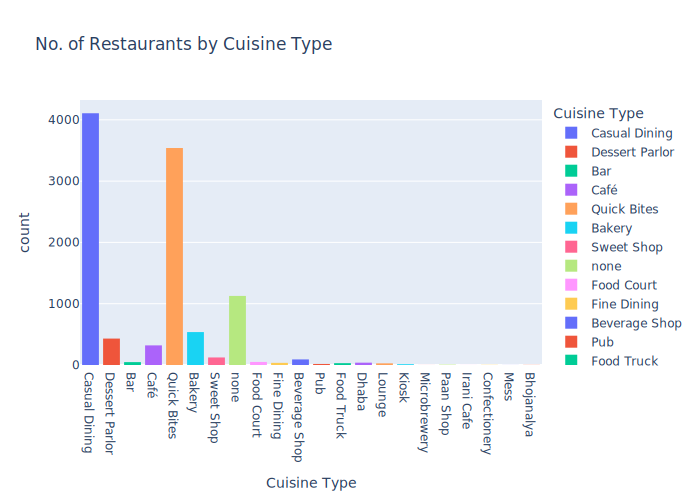

In [133]:
#5. Performing Exploratory Data Analysis
#Q1) How many restaurants are in Mumbai for each type of cuisine?
import kaleido
fig = ex.histogram(zomato_df, x='CUSINE TYPE', color='CUSINE TYPE',  
             title= 'No. of Restaurants by Cuisine Type',  
             labels={'CUSINE TYPE':'Cuisine Type'}) 
 
fig.show() 

In [134]:
#Q2) What are the percentage of restaurants by Rating Type in Mumbai?
rating_type_df = zomato_df['RATING_TYPE'].value_counts().reset_index() 
rating_type_df.rename(columns={'index':'RATING TYPE', 'RATING_TYPE':'COUNT OF RESTAURANTS'}, inplace=True) 
rating_type_df 

,COUNT OF RESTAURANTS,count
0,Average,4983
1,Good,4263
2,Very Good,1145
3,Excellent,96
4,Poor,56
5,Very Poor,4


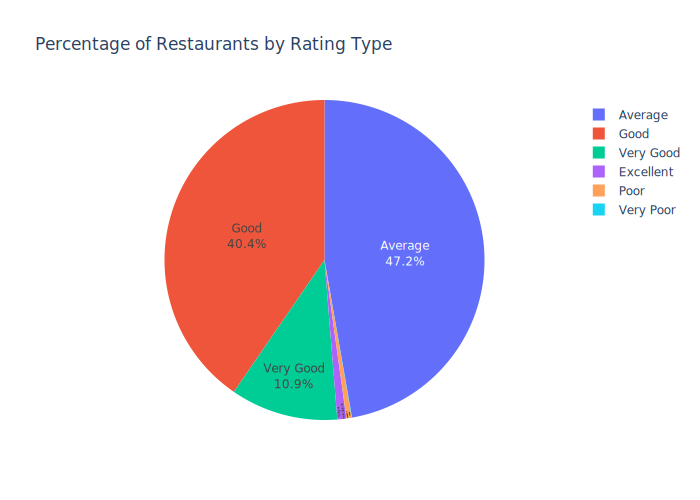

In [135]:
fig = ex.pie(rating_type_df, names='COUNT OF RESTAURANTS', values='count', color='COUNT OF RESTAURANTS',  
title='Percentage of Restaurants by Rating Type').update_traces(textposition='inside', textinfo='percent+label')
fig.show() 

In [136]:
#Q3) Which are the Top 10 highest rated Seafood Restaurant in Mumbai?

seafood_df = zomato_df[zomato_df['CUSINE_CATEGORY'].str.contains('Seafood')] 
seafood_df.sort_values(by='RATING',ascending=False).head(10)

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
7104,Thangabali,1000,"Seafood,South Indian,Mangalorean,Andhra,Kerala",Khar,Bar,"12noon to 4pm,7pm to 3am",Excellent,4.7,564,Mon-Sun
76,Ceremonial Kitchen & Co,1000,"Seafood,Maharashtrian,North Indian,Chinese",Thane,Casual Dining,1130am to 1130pm,Excellent,4.6,350,Mon-Sun
13685,Maharashtra Lunch Home,600,"Maharashtrian,Malwani,Konkan,Seafood",Kharghar,Casual Dining,"11am to 345pm,7pm to 1145pm",Excellent,4.6,209,Mon-Sun
9954,Pi Bar and Kitchen,1600,"Continental,European,Italian,Seafood,Pizza,Des...",Andheri,Bar,"12noon to 6pm,7pm to 12midnight",Excellent,4.5,2068,Mon-Sun
884,Rajmanya- Seafood family restaurant,800,"Maharashtrian,Konkan,Seafood",Vashi,Casual Dining,11am to 11pm,Excellent,4.5,178,Mon-Sun
12433,Quarter Canteen,1100,"North Indian,Seafood,Chinese",Bandra,Casual Dining,"12noon to 330pm,7pm to 1am",Excellent,4.5,573,Mon-Sun
3380,Peco Peco,700,"Chinese,Seafood,Asian",Powai,none,"12noon to 330pm,7pm to 1230AM",Excellent,4.5,497,Mon-Sun
902,The Harbour Bay - SeaFood Kitchen & Bar,2400,"Seafood,Beverages",Bandra,Casual Dining,12noon to 1am,Excellent,4.5,100,Mon-Sun
915,Monis Bar and Restaurant,1000,"North Indian,Chinese,Continental,Seafood,Bever...",Thane,Casual Dining,"1130am to 330pm,6pm to 1130pm",Very Good,4.4,662,Mon-Sun
8890,Hardeep Punjab,1100,"North Indian,Chinese,Mughlai,Seafood",Sion,Casual Dining,11am to 1am,Very Good,4.4,871,Mon-Sun


In [137]:
#Q4) Which is the best Food Truck in Mumbai?
foodtruck_df = zomato_df[zomato_df['CUSINE TYPE'] == 'Food Truck'] 
foodtruck_df.sort_values(by='RATING',ascending=False).head(2) 

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
262,Dumpling Delights,200,Momos,Matunga,Food Truck,430pm to 930pm,Very Good,4.3,212,Mon-Sun
1017,Street Food Co.,250,"Fast Food,Chinese",Virar,Food Truck,6pm to 3am,Very Good,4.1,274,Mon-Sun


In [138]:
#Q5) Which places have the highest rated restaurant for each Cuisine Type in Mumbai?
# Assuming restaurants having rating above 4.5 
 
highest_rated_df = zomato_df[zomato_df['RATING'] >= 4.5] 
highest_rated_df 

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
6,Persian Darbar,1300,"Biryani,North Indian,Chinese,Mughlai",Marol,Casual Dining,10am to 3am,Excellent,4.5,3058,Mon-Sun
7,Tanatan,1500,Modern Indian,Juhu,Casual Dining,12noon to 130am,Excellent,4.7,1842,Mon-Sun
9,Plum by Bent Chair,1800,Asian,Lower Parel,Casual Dining,12noon to 1am,Excellent,4.7,1876,Mon-Sun
10,Angrezi Dhaba,1500,"North Indian,Chinese,Thai,European",Dadar,Bar,12noon to 1am,Excellent,4.5,2092,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
14228,Zaika Crave - Club Aquaria,1300,"North Indian,Continental,Chinese,Desserts",Borivali,Casual Dining,"11am to 330pm,7pm to 1130pm",Excellent,4.5,1302,"Mon,Tue,Wed..."
14234,Cone Culture,250,European,Kharghar,Casual Dining,Closed,Excellent,4.6,492,"Mon,12noon to 11pm(Tue-Sun"
15007,Dessertino,300,"Desserts,Ice Cream",Kandivali,Dessert Parlor,11am to 12midnight,Excellent,4.8,184,Mon-Sun
15051,Tick-eat,800,"North Indian,Italian,Chinese,Mexican,Lebanese",Mulund,Casual Dining,"1130am to 330pm,7pm to 1130pm",Excellent,4.5,754,Mon-Sun


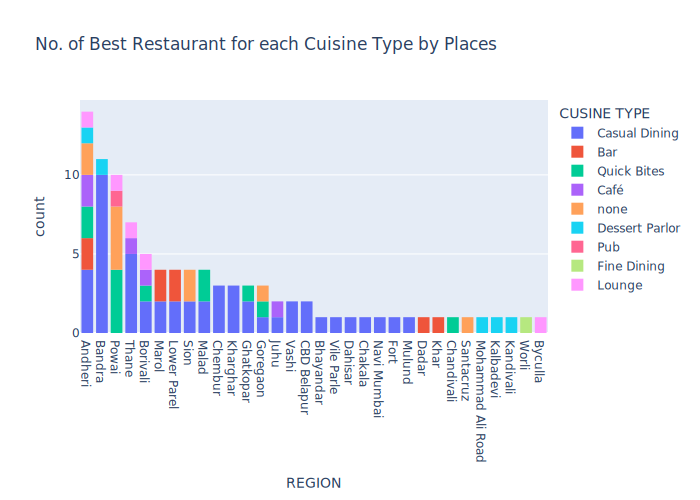

In [172]:
fig = ex.histogram(highest_rated_df, x='REGION', color='CUSINE TYPE', title= 'No. of Best Restaurant for each Cuisine Type by Places').update_xaxes(categoryorder="total descending")
fig.show() 

In [140]:
#Q6) What is the Avg Price Distibution of highest rated restaurant for each Cuisine Type in Mumbai?
highest_rated_price_df = highest_rated_df.groupby(by=['REGION', 'CUSINE TYPE'])['PRICE'].mean().reset_index() 
highest_rated_price_df.head() 

,REGION,CUSINE TYPE,PRICE
0,Andheri,Bar,1600.0
1,Andheri,Café,800.0
2,Andheri,Casual Dining,1212.5
3,Andheri,Dessert Parlor,300.0
4,Andheri,Lounge,1700.0


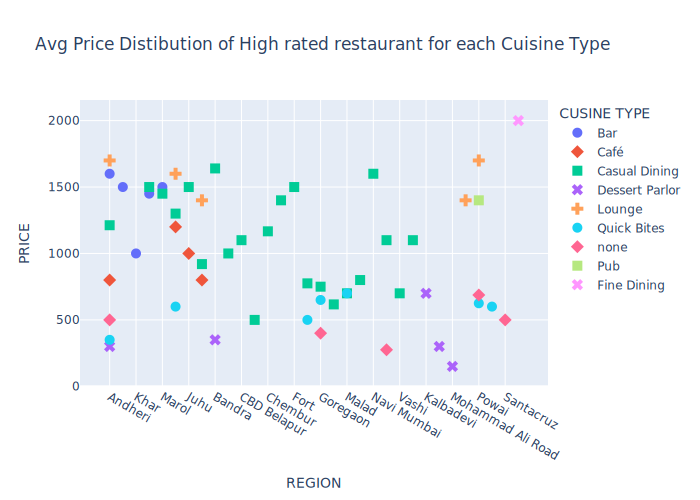

In [141]:
fig = ex.scatter(highest_rated_price_df, x="REGION", y="PRICE", color="CUSINE TYPE", symbol="CUSINE TYPE",  
           title=' Avg Price Distibution of High rated restaurant for each Cuisine Type').update_traces(marker_size=10)
 
fig.show()

In [142]:
#Q7) Which areas have a large number of Chinese Restaurant Market?
chinese_df = zomato_df[zomato_df['CUSINE_CATEGORY'].str.contains('Chinese')] 
chinese_df 

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,TIMING,RATING_TYPE,RATING,VOTES,DAYS_OPEN
0,Hitchki,1200,"Modern Indian,North Indian,Chinese,Momos,Birya...",Bandra,Casual Dining,12noon to 130am,Excellent,4.9,3529,Mon-Sun
2,Chin Chin Chu,1800,"Asian,Chinese",Juhu,Casual Dining,12noon to 1am,Very Good,4.2,337,Mon-Sun
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra,Bar,1130am to 1am,Very Good,4.4,5995,Mon-Sun
5,Flea Bazaar Café,800,"American,Asian,Street Food,North Indian,Luckno...",Lower Parel,Café,12noon to 1am,Very Good,4.2,2042,Mon-Sun
6,Persian Darbar,1300,"Biryani,North Indian,Chinese,Mughlai",Marol,Casual Dining,10am to 3am,Excellent,4.5,3058,Mon-Sun
...,...,...,...,...,...,...,...,...,...,...
15071,Lucknow Zaika,500,"North Indian,Chinese",Kurla,Quick Bites,12noon to 2am,Average,2.6,36,Mon-Sun
15072,Zuha's Kitchen,400,"Chinese,North Indian,Mughlai",Mumbai Central,Quick Bites,"12noon to 4pm,730pm to 430am",Average,3.3,13,Mon-Sun
15075,Tirupati Balaji,500,"Chinese,Fast Food,North Indian",Andheri,Casual Dining,"8am to 11pm,12midnight to 115am",Good,3.5,267,Mon-Sun
15076,Hari Om Snack Bar,350,"Fast Food,South Indian,Chinese",Kandivali,Quick Bites,11am to 230am,Good,3.7,64,Mon-Sun


In [143]:
chinese_rest_df = chinese_df.groupby(by='REGION').agg({'NAME' : 'count', 'PRICE' : 'mean'}).rename(columns= {'NAME' : 'COUNT OF RESTAURANTS'})
chinese_rest_df = chinese_rest_df.sort_values('COUNT OF RESTAURANTS', ascending=False).head(25)
chinese_rest_df.head() 

,COUNT OF RESTAURANTS,PRICE
REGION,,
Thane,371,590.983827
Sion,276,569.311594
Mira Road,224,553.348214
Malad,186,604.032258
Goregaon,163,548.773006


In [144]:
chinese_rest_df.columns

Index(['COUNT OF RESTAURANTS', 'PRICE'], dtype='str')

In [145]:
chinese_rest_df=chinese_rest_df.reset_index()

In [146]:
print(chinese_rest_df.columns)

Index(['REGION', 'COUNT OF RESTAURANTS', 'PRICE'], dtype='str')


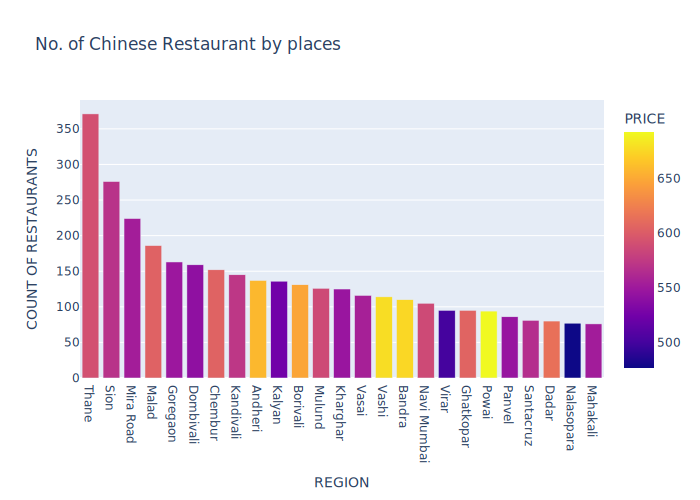

In [147]:
fig = ex.bar(chinese_rest_df, x='REGION', y='COUNT OF RESTAURANTS', color='PRICE', title= 'No. of Chinese Restaurant by places') 
fig.show() 

In [148]:
#Q8) Is there a relation between Price and Rating by each Cuisine Type?
price_rating_df = zomato_df.groupby(['CUSINE TYPE', 'RATING'])['PRICE'].mean().reset_index() 
price_rating_df

,CUSINE TYPE,RATING,PRICE
0,Bakery,2.7,400.000000
1,Bakery,2.8,285.714286
2,Bakery,2.9,328.571429
3,Bakery,3.0,300.000000
4,Bakery,3.1,369.117647
...,...,...,...
278,none,4.3,683.333333
279,none,4.4,555.000000
280,none,4.5,420.000000
281,none,4.6,687.500000


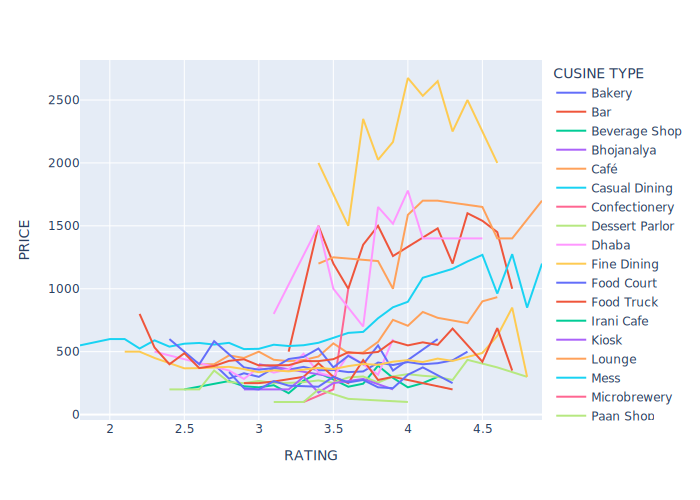

In [149]:
fig = ex.line(price_rating_df, y="PRICE", x="RATING",color='CUSINE TYPE')
fig.show()

In [150]:
#Q9) Is there a relation between Region and Price?
region_price_df = zomato_df.groupby(['REGION'])['PRICE'].mean().reset_index() 
region_price_df 

,REGION,PRICE
0,Airoli,452.287582
1,Alibaug,665.000000
2,Ambernath,514.000000
3,Andheri,590.049383
4,Bandra,724.945946
...,...,...
75,Vikhroli,480.434783
76,Vile Parle,464.457831
77,Virar,452.027027
78,Wadala,427.500000


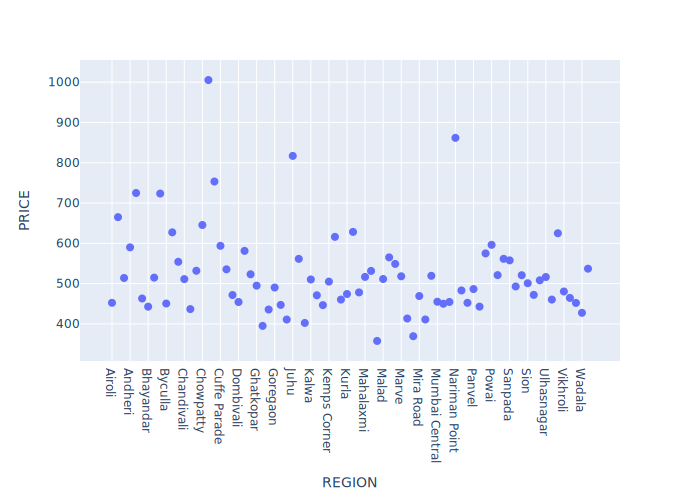

In [151]:
fig = ex.scatter(region_price_df, x="REGION", y="PRICE").update_traces(marker_size=8) 
fig.show()

In [152]:
#Q10) Find the list of Affordable Restaurants?
"""
The criteria for Affordable Restaurants would be:
1) Low Price 2) High Rated
First step will be to find the restaurants with average cost 1/4th the average cost of most expensive restaurant in our dataframe.
Let me explain:-The most expensive restaurant has an average meal cost= 6000. We'll try to stay economical and only pick the
restaurants that are 1/4th of 6000
"""

"\nThe criteria for Affordable Restaurants would be:\n1) Low Price 2) High Rated\nFirst step will be to find the restaurants with average cost 1/4th the average cost of most expensive restaurant in our dataframe.\nLet me explain:-The most expensive restaurant has an average meal cost= 6000. We'll try to stay economical and only pick the\nrestaurants that are 1/4th of 6000\n"

In [153]:
max_price = zomato_df['PRICE'].max() 
one_fourth_price = max_price/4 
one_fourth_price 

np.float64(1250.0)

In [154]:
# Finding list of restaurants that have price less than and equal to 1/4th of the max price i.e Finding Cheap Restauran
 
aff_rest_df = zomato_df[['NAME', 'PRICE', 'CUSINE_CATEGORY', 'REGION', 'CUSINE TYPE']] 
aff_rest_df = aff_rest_df[aff_rest_df['PRICE'] <= 1250] 
aff_rest_df.sort_values(by='PRICE', inplace=True) 
aff_rest_df 

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE
6137,Sanjog Wine N Dine,5,"North Indian,Chinese",Thane,Casual Dining
2925,Jab We Eat,50,"South Indian,North Indian,Maharashtrian,Fast Food",Girgaum,none
9598,Ho5 Store,50,Fast Food,Matunga,none
10996,Pandurang Wada Pav And Sandwich Centre,100,Street Food,Goregaon,Quick Bites
3328,Gurukrupa Sandwich And Frankie Corner,100,"Rolls,Fast Food",Sion,none
...,...,...,...,...,...
4,BKC DIVE,1200,"North Indian,Chinese,Continental",Bandra,Bar
17,Ustaadi,1200,"Asian,Biryani,Chinese,North Indian,Mughlai,Mid...",Mumbai Central,Casual Dining
7301,SamBar Pub & Kitchen,1250,"Finger Food,South Indian,North Indian",Khar,Pub
6045,Fabelle at The Chocolate Boutique - ITC Grand ...,1250,Desserts,Parel,Dessert Parlor


In [155]:
 # Finding the highest rated list of restaurants 
 
highrate_rest_df = zomato_df[['NAME', 'PRICE', 'CUSINE_CATEGORY', 'REGION', 'CUSINE TYPE','RATING']] 
highrate_rest_df = highrate_rest_df[highrate_rest_df['RATING'] >= 4.5] 
highrate_rest_df.sort_values(by='PRICE', inplace=True) 
highrate_rest_df 

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,RATING
1502,Cake Centre-The Dessert Maker,150,Desserts,Mohammad Ali Road,Dessert Parlor,4.6
807,Moussestruck,200,Desserts,Sion,none,4.5
763,Curry And Combos Twist,200,"North Indian,Chinese",Andheri,Quick Bites,4.5
14234,Cone Culture,250,European,Kharghar,Casual Dining,4.6
725,Belo Pops,300,"Ice Cream,Desserts,Beverages",Andheri,none,4.5
...,...,...,...,...,...,...
8887,Drifters Tap Station,2000,"North Indian,Continental,European,American",Bandra,Casual Dining,4.5
1786,Global Fusion,2000,"Chinese,Japanese,Asian,North Indian",Worli,Fine Dining,4.6
5335,Mia Cucina,2000,Italian,Bandra,Casual Dining,4.5
12625,House of Mandarin,2100,"Chinese,Sushi,Asian",Bandra,Casual Dining,4.5


In [156]:
"""
Now, we'll merge the aff_rest_df with highrate_rest_df to obtain the intersection i.e the list of Affordable Restaurants !!
"""
highrate_aff_df = pd.merge(aff_rest_df, highrate_rest_df, how='inner', on=['NAME', 'REGION']) 
highrate_aff_df = highrate_aff_df[['NAME', 'PRICE_x', 'CUSINE_CATEGORY_x', 'REGION', 'CUSINE TYPE_x']] 
highrate_aff_df.rename(columns={'NAME':'NAME', 'PRICE_x':'PRICE', 'CUSINE_CATEGORY_x':'CUSINE_CATEGORY',  
                                'REGION':'REGION', 'CUSINE TYPE_x':'CUSINE TYPE'},inplace=True) 

In [157]:
 # Affordable Restaurants with low price and high rating  
 
highrate_aff_df 

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE
0,Cake Centre-The Dessert Maker,150,Desserts,Mohammad Ali Road,Dessert Parlor
1,Curry And Combos Twist,200,"North Indian,Chinese",Andheri,Quick Bites
2,Moussestruck,200,Desserts,Sion,none
3,Cone Culture,250,European,Kharghar,Casual Dining
4,Dessertino,300,"Desserts,Ice Cream",Kandivali,Dessert Parlor
...,...,...,...,...,...
60,Culinary Tales,1200,"Chinese,European,Continental,Salad,Italian,Pizza",Sion,Casual Dining
61,Wild Dining Restaurant,1200,"North Indian,Continental,Mexican,Chinese",Andheri,Casual Dining
62,The Joker Bistro,1200,"North Indian,Chinese,Continental",CBD Belapur,Casual Dining
63,Invento,1200,"Chinese,Fast Food,North Indian,Italian,Mexican",Lower Parel,Casual Dining


In [158]:
"""
Q10) Find the list of most Reliable Restaurants?
The criteria for most Reliable Restaurants would be:
1) Low Price 2) High Rated 3) Large No. of Votes
First step will be to find the restaurants with Votes greater than Mean of Votes
"""

'\nQ10) Find the list of most Reliable Restaurants?\nThe criteria for most Reliable Restaurants would be:\n1) Low Price 2) High Rated 3) Large No. of Votes\nFirst step will be to find the restaurants with Votes greater than Mean of Votes\n'

In [159]:
mean_votes = zomato_df['VOTES'].mean() 
mean_votes 

np.float64(177.2656679624538)

In [160]:
# Finding list of restaurants that have Votes greater than and equal to  Mean of Vote 
 
mean_rest_df = zomato_df[['NAME', 'PRICE', 'CUSINE_CATEGORY', 'REGION', 'CUSINE TYPE', 'VOTES']] 
mean_rest_df = mean_rest_df[mean_rest_df['VOTES'] > 177] 
mean_rest_df.sort_values(by='VOTES', inplace=True) 
mean_rest_df 

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE,VOTES
99,Appetite - Resto Bar,700,"North Indian,Chinese",Powai,Casual Dining,178
12267,Buddha Bowl,1000,"Asian,Healthy Food",Bandra,none,178
2193,Mumbai Darbar,850,"North Indian,Chinese,Seafood",Lower Parel,Casual Dining,178
11211,Soul Curry,800,"Chinese,North Indian,Malwani,Mughlai,Biryani",Bhandup,Casual Dining,178
2392,Jain Sweet & Farsan House,200,"Street Food,Beverages,Fast Food,Mithai",Goregaon,Quick Bites,178
...,...,...,...,...,...,...
8539,Leopold Cafe & Bar,1600,"American,Chinese,Mughlai,Italian",Colaba,Casual Dining,7327
1251,Joey's Pizza,800,Pizza,Malad,Quick Bites,7350
5337,Chili's American Grill & Bar,1400,"American,Mexican,Burger,Tex-Mex",Powai,Casual Dining,7377
3751,Prithvi Cafe,700,"Cafe,Fast Food",Juhu,Café,8000


In [161]:
"""
These are the most reliable, highest rated and affordable restaurants:
We obtain this dataframe by simply taking the intersection of highrate_aff_df & mean_rest_df
This dataframe obtained below shows the restaurants whose:
Cost is below 1250
Rating is above 4.5
Votes are above 177
"""
reliable_rest_df = pd.merge(mean_rest_df, highrate_aff_df, how='inner', on=['NAME', 'REGION']) 
reliable_rest_df = reliable_rest_df[['NAME', 'PRICE_x', 'CUSINE_CATEGORY_x', 'REGION', 'CUSINE TYPE_x']] 
reliable_rest_df.rename(columns={'NAME':'NAME', 'PRICE_x':'PRICE', 'CUSINE_CATEGORY_x':'CUSINE_CATEGORY',  
                                'REGION':'REGION', 'CUSINE TYPE_x':'CUSINE TYPE'},inplace=True) 

In [162]:
reliable_rest_df

,NAME,PRICE,CUSINE_CATEGORY,REGION,CUSINE TYPE
0,Rajmanya- Seafood family restaurant,800,"Maharashtrian,Konkan,Seafood",Vashi,Casual Dining
1,Fresh Food Co.,500,"Continental,Healthy Food,Salad,Beverages,Desse...",Santacruz,none
2,Dessertino,300,"Desserts,Ice Cream",Kandivali,Dessert Parlor
3,Invento,1200,"Chinese,Fast Food,North Indian,Italian,Mexican",Lower Parel,Casual Dining
4,Maharashtra Lunch Home,600,"Maharashtrian,Malwani,Konkan,Seafood",Kharghar,Casual Dining
5,Regano's,600,"Continental,Fast Food,Italian,Desserts",Malad,Casual Dining
6,Big Bang Cuurry,350,"North Indian,Biryani,Rolls",Sion,none
7,Sandy's Den,1000,"Fast Food,Bar Food",Chembur,Casual Dining
8,Angrezi Patiyalaa,1200,"North Indian,Finger Food,American,Mexican,Chinese",Andheri,Casual Dining
9,Maezo,1000,Modern Indian,Thane,Casual Dining
